In [ ]:
gitimport pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

#import functions
from data_preprocessing import prepare_X, get_labels, clean_text, lemmatize

## Load Data

In [10]:
data_train = pd.read_csv('dataset/data.csv', encoding="utf8")
data_inference = pd.read_csv('dataset/validation_data.csv', encoding="utf8")

## Prepare Data

In [11]:
X_prepared = prepare_X(data_train)
labels_train = get_labels(data_train, X_prepared.index)
X_prepared = X_prepared.reset_index(drop=True) 

## Train-Test-Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_prepared['text'], labels_train, test_size=0.2, random_state=42
)

## Data-cleaning and Lemmatization

In [13]:
#load cleaned and lemmatized data

X_train_clean = pd.read_csv('dataset/X_train_cleaned.csv').squeeze("columns").fillna("")
X_test_clean = pd.read_csv('dataset/X_test_cleaned.csv').squeeze("columns").fillna("")


## Word Embeddings (Word2Vec)

In [ ]:
train_tokens = [text.split() for text in X_train_clean]
test_tokens = [text.split() for text in X_test_clean]

w2v_model = Word2Vec(sentences=train_tokens, vector_size=100, window=5, min_count=1, workers=4)

def vectorize_text(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X_train_vec = np.array([vectorize_text(tokens, w2v_model) for tokens in train_tokens])
X_test_vec = np.array([vectorize_text(tokens, w2v_model) for tokens in test_tokens])

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


## Train models and make predictions

In [23]:
logistic_model = LogisticRegression()
logistic_model.fit(X_train_vec, y_train)

#predictions
predictions = logistic_model.predict(X_test_vec)
print(f"Logistic Regression Accuracy (Word Embeddings): {accuracy_score(y_test, predictions):.4f}")
print("\nClassification Report:\n", classification_report(y_test, predictions))

Logistic Regression Accuracy (Word Embeddings): 0.9684

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97      3297
           1       0.97      0.97      0.97      3989

    accuracy                           0.97      7286
   macro avg       0.97      0.97      0.97      7286
weighted avg       0.97      0.97      0.97      7286



## Confusion matrix

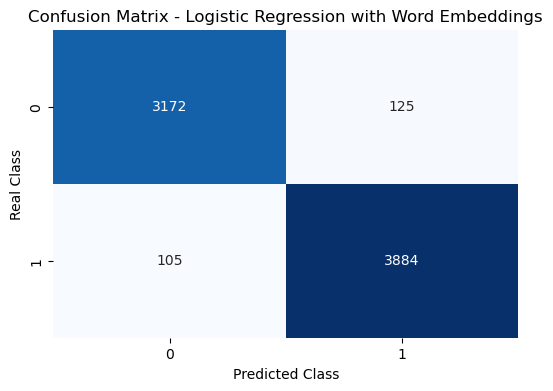

In [ ]:
conf_matrix = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=logistic_model.classes_, 
            yticklabels=logistic_model.classes_)

plt.xlabel('Predicted Class')
plt.ylabel('Real Class')
plt.title('Confusion Matrix - Logistic Regression with Word Embeddings')
plt.show()

## Look at examples from Inference Set

In [25]:
# load dataset
inference_data = pd.read_csv('dataset/validation_data.csv', encoding="utf8")

mini_inference_set = inference_data.sample(n=20, random_state=42)

In [26]:
# prepare the subset
mini_prepared = prepare_X(mini_inference_set)

mini_clean = mini_prepared['text'].apply(clean_text).apply(lemmatize)


In [27]:
#vectorize mini set
mini_tokens = [text.split() for text in mini_clean]

X_mini_vec = np.array([vectorize_text(tokens, w2v_model) for tokens in mini_tokens])


In [28]:
# make predictions on mini set

In [29]:
mini_preds = logistic_model.predict(X_mini_vec)

## Examples

In [22]:
# show predictions
for i, (idx, row) in enumerate(mini_inference_set.iterrows()):
    pred_label = mini_preds[i]
    print(f"\n[News {i+1}] - Model prediction: {pred_label}")
    print(f"Article: {row['text'][:200]}...")
    print("-" * 50)


[News 1] - Model prediction: 0
Article: This is so over the top it s not funny. I m a huge advocate of parents being there for the kids but a felony charge? Held overnight in jail? Does anyone out there have anything new to add to this or i...
--------------------------------------------------

[News 2] - Model prediction: 0
Article: I m pretty sure Trump will win with a YUGE majority in New York without his kids votes. Eric Trump and Ivanka Trump won t be voting for their father, Donald, in the New York primary next week.The dead...
--------------------------------------------------

[News 3] - Model prediction: 0
Article: Pray for these police officers, the innocent citizens, residents and business owners in Baltimore Here is a recruitment flyer that was posted by the Black Panthers leading up to the start of the riots...
--------------------------------------------------

[News 4] - Model prediction: 0
Article: Trump spoke to his supporters at a rally in Cleveland, Ohio, on Saturda